# mSSA Run for two-armed phase spiral amplitude caused by the first passage

In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
sys.path.append('../../code/')
import importlib
import helper

In [2]:
directory = '../../data/mssa_channels_B2/'

fname_m2_amp = directory+'m2_amp_first_passage_bins_j30_t16.dat'
fname_m2_rel_amp = directory+'m2_amp_rel_first_passage_bins_j30_t16.dat'

# coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m2_amp0 = pyEXP.coefs.Coefs.factory(fname_m2_amp)

# coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()

coefs = coefs_m2_amp0.deepcopy()
fname = fname_m2_amp

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [3]:
n_channels = int(len(coefs.getAllCoefs()))
times = coefs.Times()

keylst = [[i] for i in range(n_channels)]

config = {"m2_amp": (coefs, keylst, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [4]:
fig_dir = '../../figures/B2_figures/m2_amp_first_passage_window0p5/'

In [5]:
ev = mssa.eigenvalues()

shape U = 52080 x 106
shape Y = 106 x 52080


In [6]:
coefs.zerodata()
mssa.reconstruct([*range(30)])

In [7]:
def make_ev_and_wCorr_plots(ev, mssa, fig_dir=fig_dir):
    fig, [ax1, ax2] = plt.subplots(1,2,figsize=(12,5))
    ax1.semilogy(ev[:30], '-o')
    ax1.set_xlabel('index', fontsize=20)
    ax1.set_ylabel('eigenvalue', fontsize=20)
    ax1.set_title('PC Eigenvalues', fontsize=20)

    ax2.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')

    plt.savefig(fig_dir+'ev+wcorr.png')
    plt.show()

In [8]:
make_ev_and_wCorr_plots(ev, mssa)

/var/folders/f1/wqzqbly11d9__jf5mjckhwvm0000gq/T/ipykernel_10134/1069561670.py:11: UserWarning: FigureCanvasPdf is non-interactive, and thus cannot be shown
  plt.show()



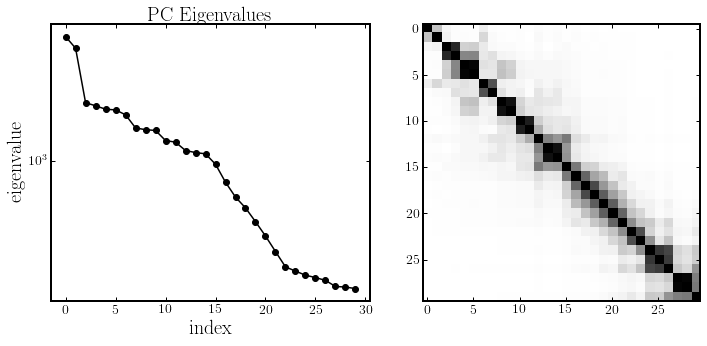

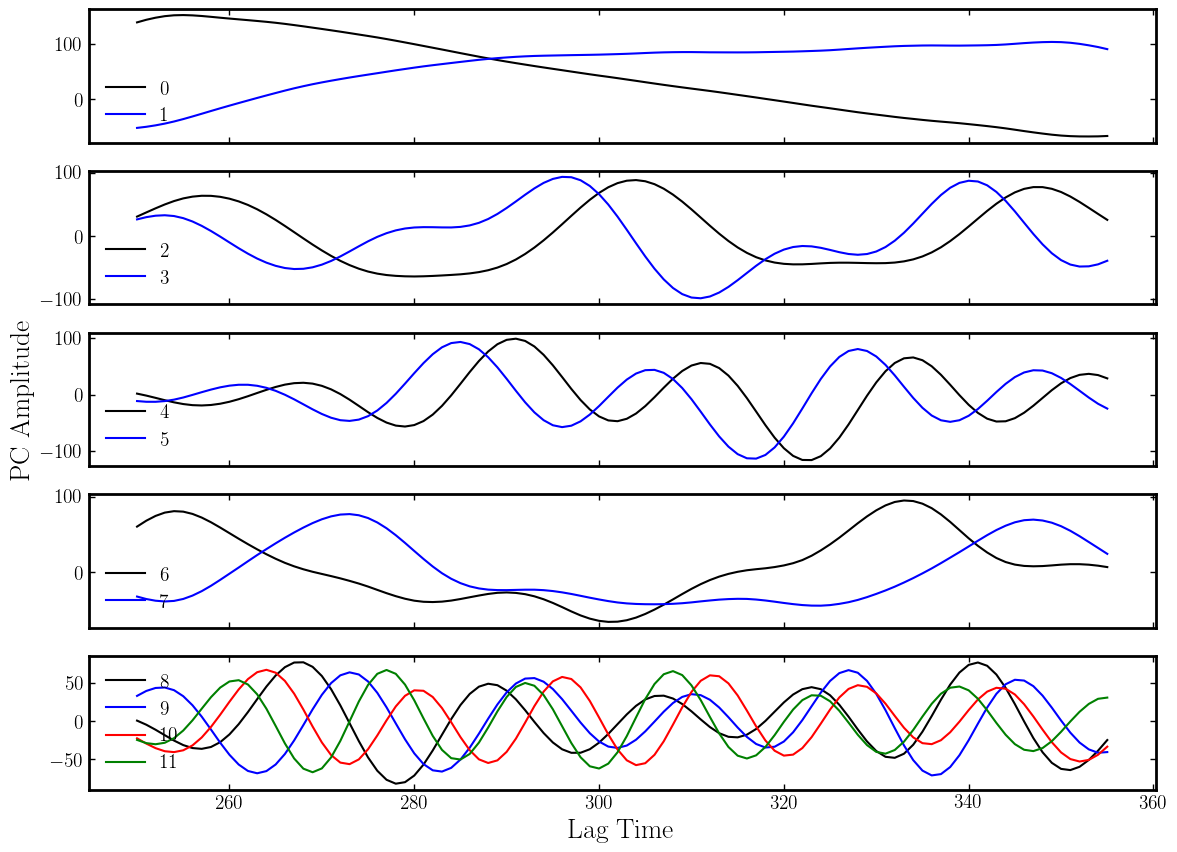

In [9]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(12, 1.75*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

# plt.suptitle('PCs, m1 amp / m2 amp', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

axs[2].set_ylabel('PC Amplitude', fontsize=20)
for i in range(n_plots):
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

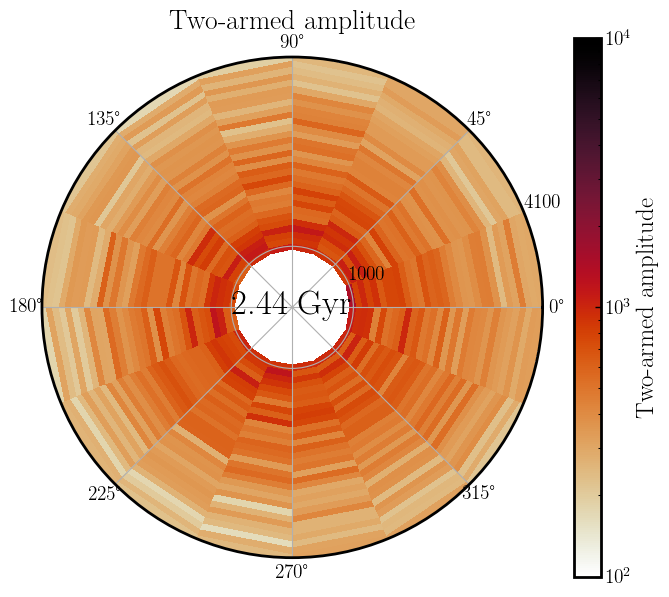

In [12]:
importlib.reload(sys.modules['helper'])
from helper import *

data_tbl = np.loadtxt(fname)

f = fig_dir+'face-on_plots/data.mp4'
norm_function = mpl.colors.LogNorm
cmap = cmr.sunburst_r
vmin= 1e2 ; vmax=1e4

MakeAnim = MakeAnimations(mssa=mssa, sim_name='B2', channel_name='Two-armed amplitude', times=times, jphi_min=1000, jbins=31)
MakeAnim.make_data_mov(f, data_tbl, norm_function=norm_function, cmap=cmap, vmin=vmin, vmax=vmax)

In [13]:
print(data_tbl.min(), data_tbl.max())

153.38547481652824 14675.760114963832


Updating for: (c)_0
Updating for: (s)_0
Updating for: ()_0
Updating for: ()_0
Updating for: (`)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (6)_0
Updating for: (t)_0
Updating for: (�)_0
Updating for: (t)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (~)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (0)_0
Updating for: ()_0
Updating for: (`)_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (9)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


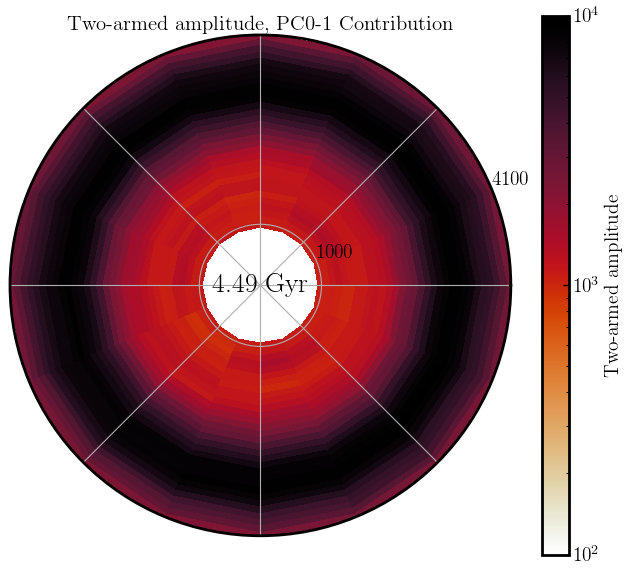

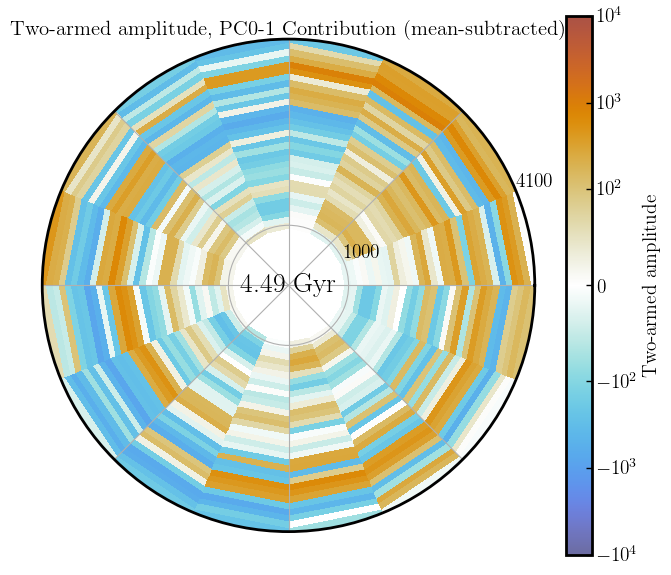

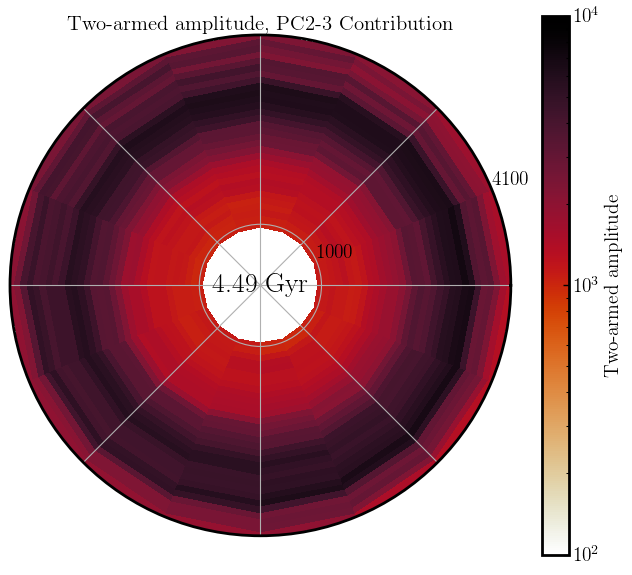

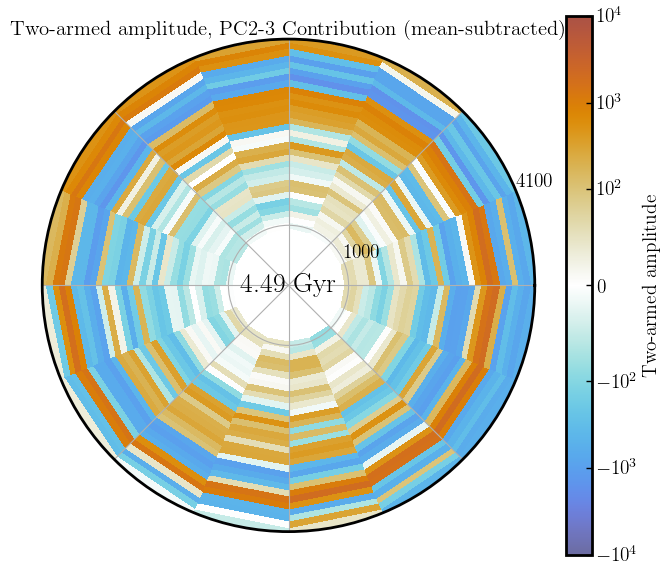

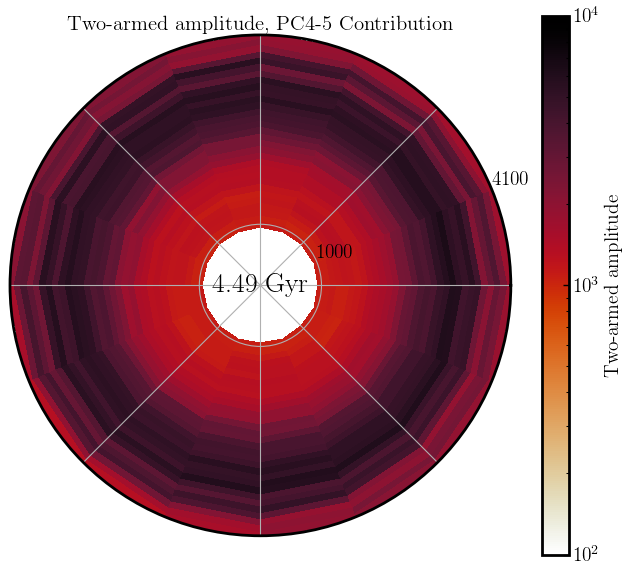

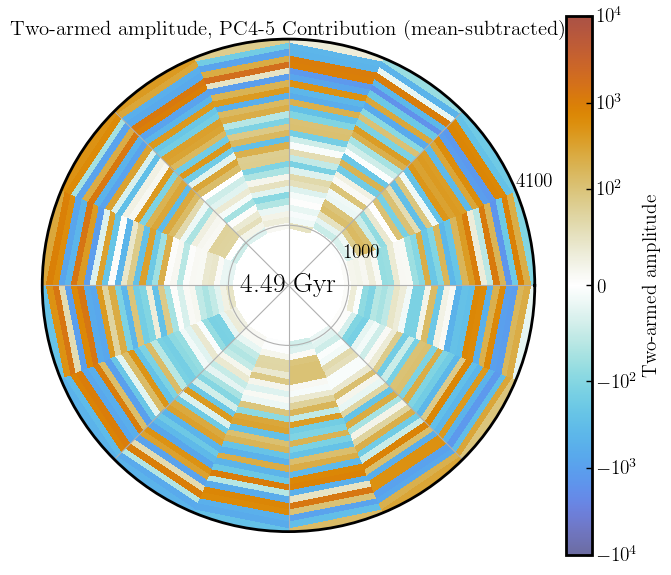

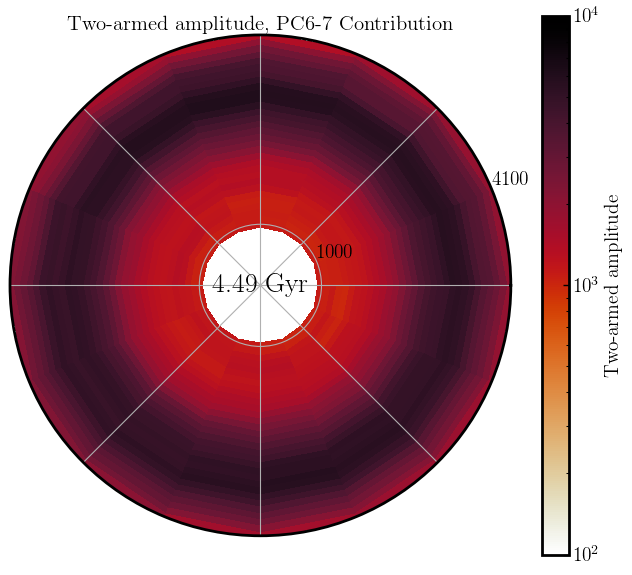

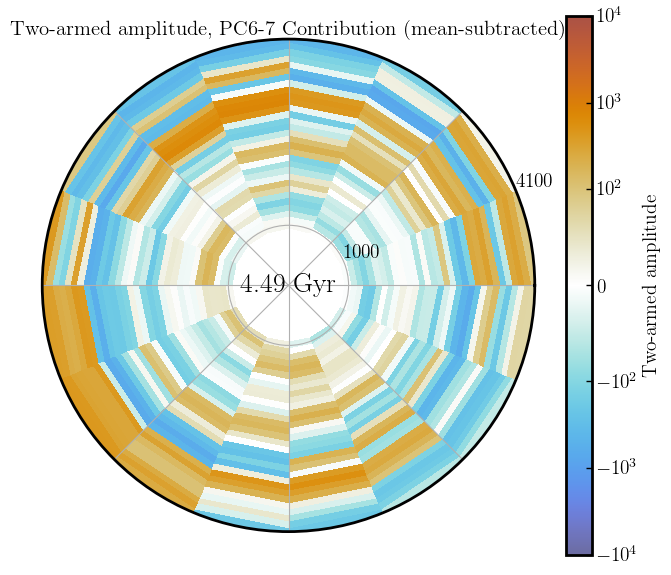

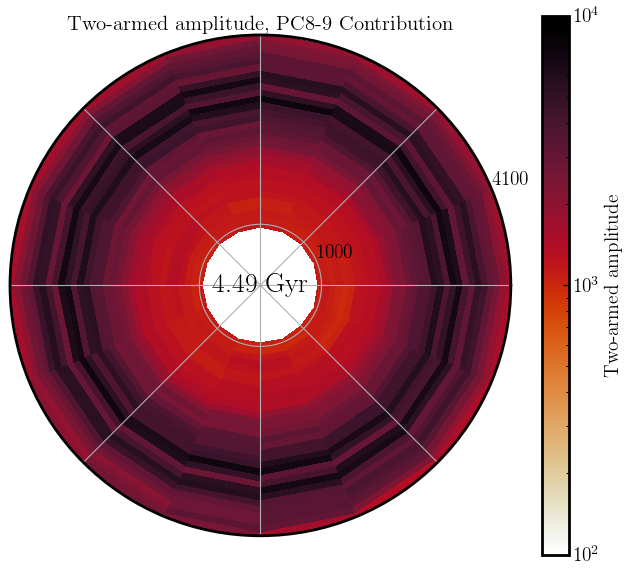

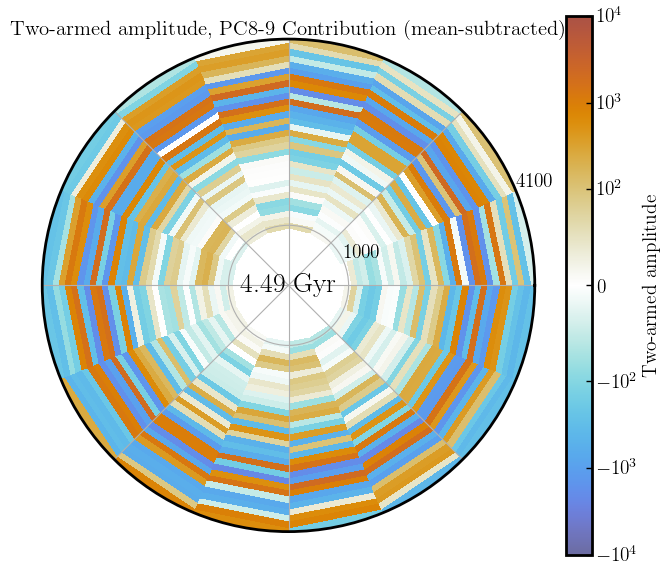

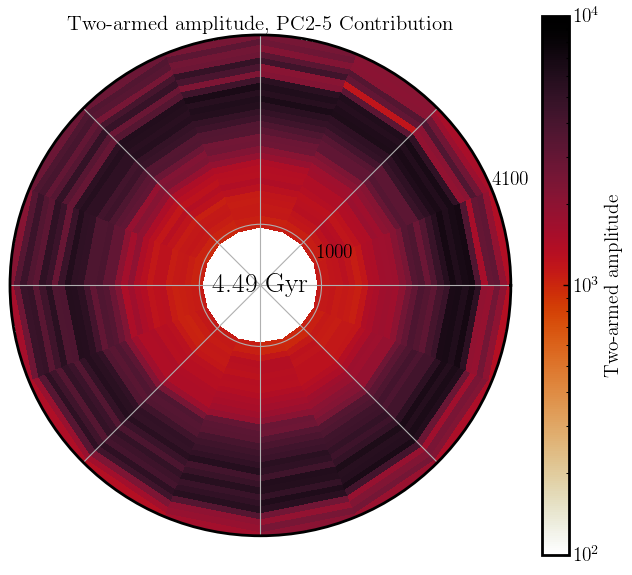

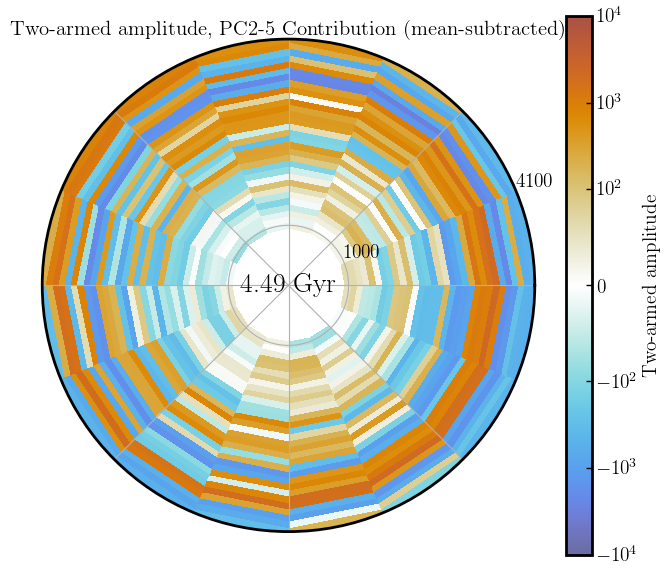

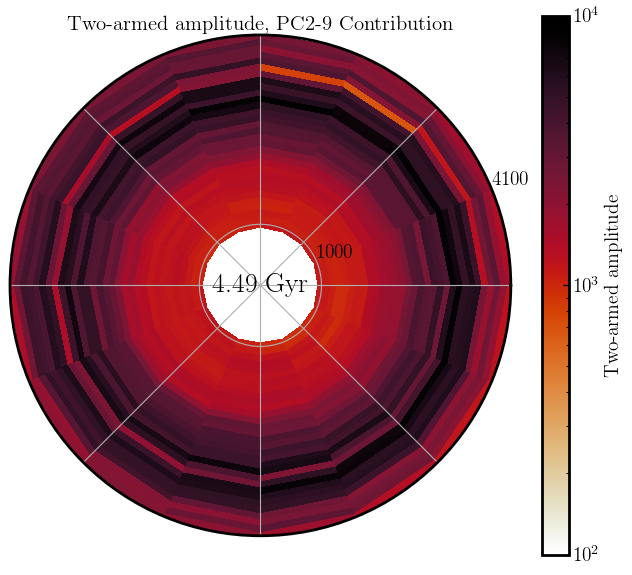

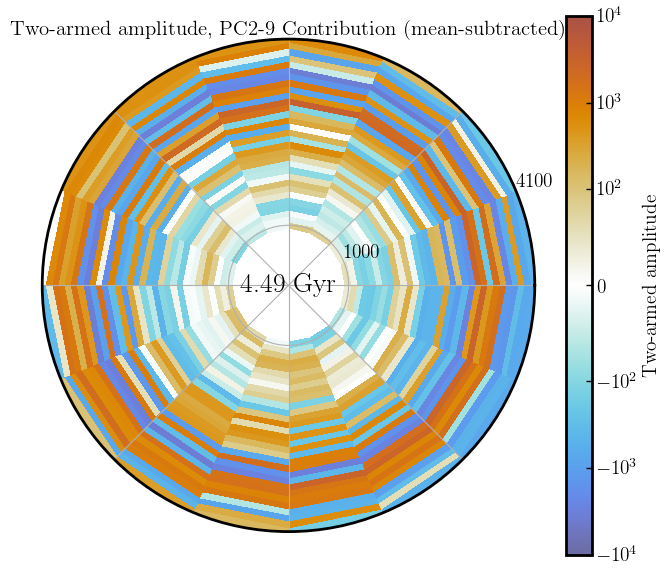

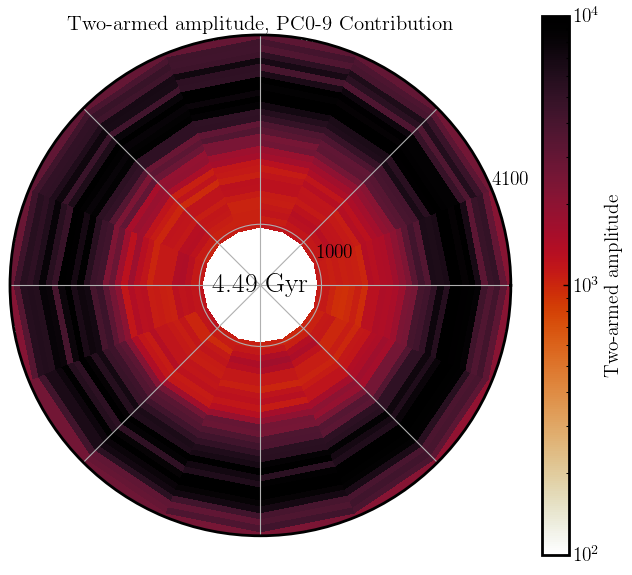

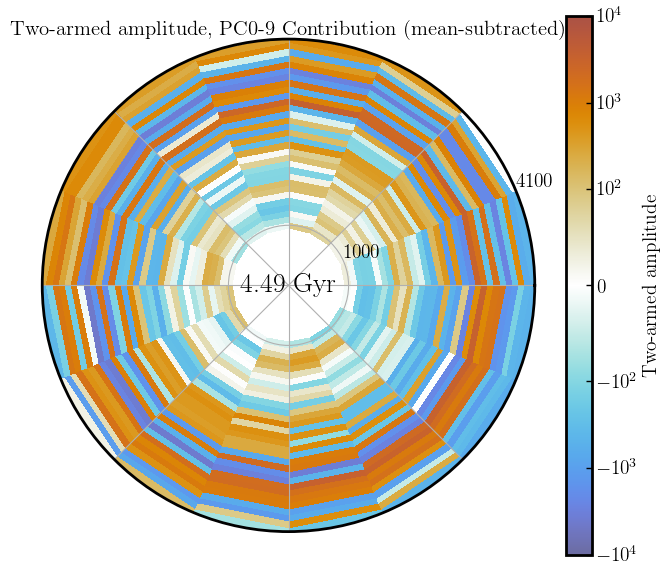

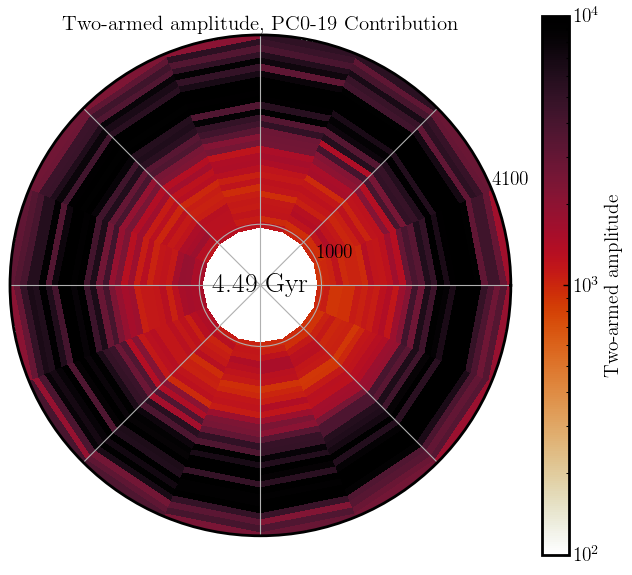

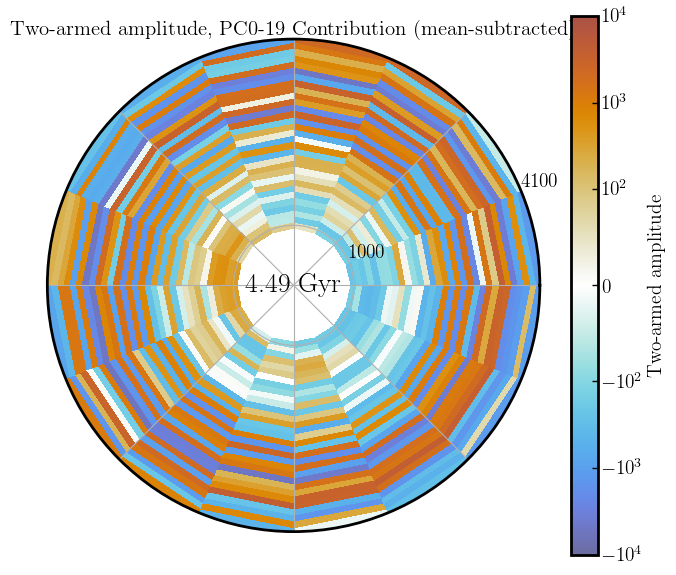

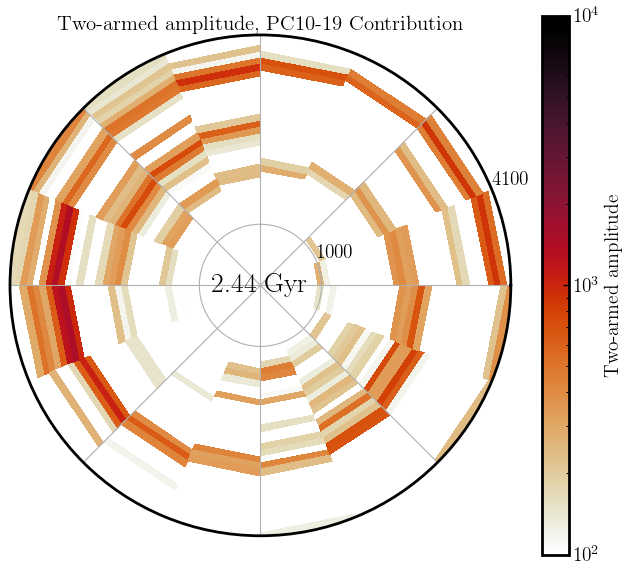

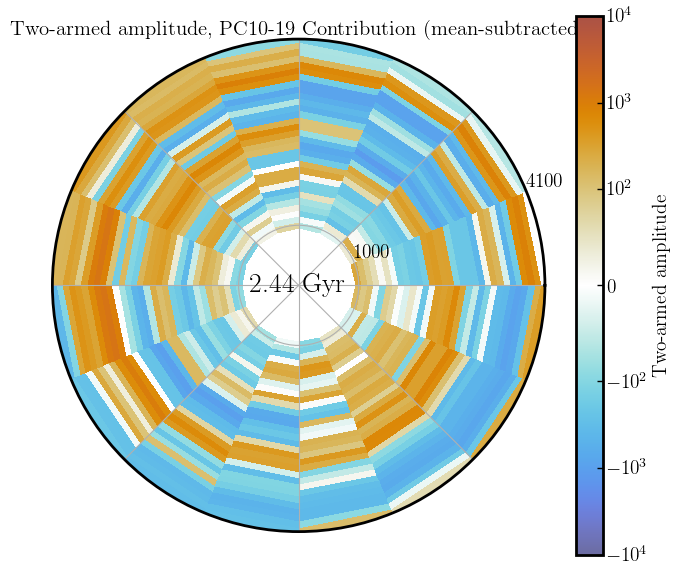

In [11]:
importlib.reload(sys.modules['helper'])
from helper import *

file_dir = fig_dir+'face-on_plots/'

list_of_pc_lists = list(([0,1], [2,3], [4,5], [6,7], [8,9], 
                         list(range(2,6)), list(range(2,10)), 
                         list(range(0,10)), list(range(0,20)), 
                         list(range(10,20))))

for pc_list in list_of_pc_lists:
    MakeAnim.reconstruct_from_pcs(pcs=pc_list)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                        norm_function=mpl.colors.LogNorm, cmap=cmr.sunburst_r, vmin=vmin, vmax=vmax)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True, 
                                        norm_function=mpl.colors.SymLogNorm, cmap=cmr.prinsenvlag_r, vmin=-1e4, vmax=1e4, linthresh=1e2)
